In [3]:
CLUSTERING_ALGO = "kmeans"
FEAT_ENG_ALGO = "ssnn"

In [2]:
!pip install clustering-benchmarks -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 95.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 64.5 MB/s eta 0:00:00


In [1]:
import clustbench
data_url = "https://github.com/gagolews/clustering-data-v1/raw/v1.1.0"

In [2]:
battery_datasets_dict = {
                         'fcps': ['atom', 'chainlink', 'engytime', 'hepta', 'lsun', 'target', 'tetra', 'twodiamonds', 'wingnut'],
                         'uci': ['ecoli', 'glass', 'ionosphere', 'sonar', 'statlog', 'wdbc', 'wine', 'yeast'],
                         }

# TabPFN: install and test

In [5]:
# Install tabpfn from source
# Clone the repository: shallow for speedup
!git clone --depth 1 https://github.com/PriorLabs/tabpfn

# Speeding up installation in this notebook:
# Remove torch dependency as it is already installed on colab (do not run this in your local setup)
!sed -i "/torch/d" tabpfn/pyproject.toml

# Step 3: Install using the correct directory name 'tabpfn'
!uv pip install -e "tabpfn"

# Install TabPFN extensions for additional functionalities
!git clone https://github.com/PriorLabs/tabpfn-extensions

# Speeding up installation in this notebook:
# Remove torch dependency as it is already installed on colab (do not run this in your local setup)
!sed -i "/torch/d" tabpfn-extensions/pyproject.toml

!uv pip install -e tabpfn-extensions[all]

Cloning into 'tabpfn'...
remote: Enumerating objects: 130, done.
remote: Counting objects: 100% (130/130), done.
remote: Compressing objects: 100% (118/118), done.
remote: Total 130 (delta 10), reused 60 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (130/130), 1.71 MiB | 5.68 MiB/s, done.
Resolving deltas: 100% (10/10), done.
Using Python 3.12.12 environment at: /usr
Resolved 37 packages in 671ms
Prepared 6 packages in 1.70s
Uninstalled 1 package in 8ms
Installed 6 packages in 16ms
 + backoff==2.2.1
 + eval-type-backport==0.2.2
 + posthog==6.7.11
 - requests==2.32.4
 + requests==2.32.5
 + tabpfn==2.2.1 (from file:///content/tabpfn)
 + tabpfn-common-utils==0.2.4
Cloning into 'tabpfn-extensions'...
remote: Enumerating objects: 3745, done.
remote: Counting objects: 100% (1272/1272), done.
remote: Compressing objects: 100% (481/481), done.
remote: Total 3745 (delta 1027), reused 806 (delta 776), pack-reused 2473 (from 5)
Receiving objects: 100% (3745/3745), 1.44 MiB | 4.00 MiB/

In [4]:
try:
    from tabpfn_extensions.post_hoc_ensembles.sklearn_interface import (
        AutoTabPFNClassifier,
    )

    from tabpfn import TabPFNClassifier, TabPFNRegressor
except ImportError:
    raise ImportError(
        "Warning: Could not import TabPFN / TabPFN extensions. Please run installation above and restart the session afterwards (Runtime > Restart Session)."
    )

In [5]:
# Simple import for TabPFN
from tabpfn import TabPFNClassifier

# Now you can use it like any other sklearn classifier
# model = TabPFNClassifier()
print("TabPFNClassifier imported successfully.")

TabPFNClassifier imported successfully.


In [6]:
b = clustbench.load_dataset("uci", "wine", url=data_url)
X, y = b.data, b.labels[0]

In [23]:
X

array([[ 5.69758670e-03, -2.90182020e-03,  2.94118898e-04, ...,
         3.82881929e-04,  6.06305804e-03,  1.47412979e+00],
       [ 9.24483429e-04, -2.57771248e-03, -1.04978498e-03, ...,
         4.28472940e-04,  3.65290190e-03,  1.40461922e+00],
       [ 7.38422182e-04,  1.08693774e-04,  1.40710369e-03, ...,
         3.35902980e-04,  2.58829216e-03,  2.03021979e+00],
       ...,
       [ 1.24796224e-03,  9.00662885e-03, -4.93751496e-04, ...,
        -1.70238084e-03, -4.87344152e-03,  4.08293228e-01],
       [ 7.85929668e-04,  1.17579480e-03,  1.59793445e-05, ...,
        -1.65622118e-03, -4.59510619e-03,  4.31463491e-01],
       [ 5.23480161e-03,  8.17321144e-03,  1.73071469e-03, ...,
        -1.61008291e-03, -4.68837747e-03, -8.66076834e-01]])

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Train and evaluate the TabPFN classifier
tabpfn_classifier = TabPFNClassifier(random_state=42)
tabpfn_classifier.fit(X_train, y_train)
y_pred_proba = tabpfn_classifier.predict_proba(X_test)

# Calculate the ROC AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
print(f"TabPFN ROC AUC Score: {roc_auc:.4f}")

tabpfn-v2-classifier-finetuned-zk73skhh.(…):   0%|          | 0.00/29.0M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

TabPFN ROC AUC Score: 1.0000


In [8]:
X_train.shape

(142, 13)

In [13]:
from tabpfn_extensions.embedding import TabPFNEmbedding

embedding_extractor = TabPFNEmbedding(tabpfn_clf=tabpfn_classifier, n_fold=0)
train_embeddings = embedding_extractor.get_embeddings(
    X_train,
    y_train,
    X_test,
    data_source="train",
)
test_embeddings = embedding_extractor.get_embeddings(
    X_train,
    y_train,
    X_test,
    data_source="test",
)

In [14]:
# The embeddings have shape (n_splits, n_samples, n_features), so we use the first split [0].
train_embeddings.shape

#model.fit(train_embeddings[0], y_train)
#y_pred = model.predict(test_embeddings[0])

(8, 142, 192)

## Create embeddings using TabPFN

In [25]:
import numpy as np
from tabpfn import TabPFNClassifier, TabPFNRegressor
from tabpfn_extensions.embedding import TabPFNEmbedding
import pandas as pd

def ssnn_feat_eng(X):

  # To store embeddings for each feature
  embeddings_list = []

  # Get the number of features
  n_samples, n_features = X.shape

  for feature_idx in range(n_features):

      # Prepare input by removing the current feature
      X_in = np.delete(X, feature_idx, axis=1)  # shape: (n_samples, n_features-1)

      # Target is the left-out feature
      y_target = X[:, feature_idx]  # shape: (n_samples,)

      # Define TabPFN
      tabpfn = TabPFNRegressor(random_state=42)
      tabpfn.fit(X_in, y_target)

      embedding_extractor = TabPFNEmbedding(tabpfn_reg=tabpfn, n_fold=0)
      train_embeddings = embedding_extractor.get_embeddings(
          X_in, # Use X_in for training the embedding extractor
          y_target, # Use y_target for training the embedding extractor
          X_in, # Use X_in for generating embeddings
          data_source="train",
      )

      # Append embeddings
      embeddings_list.append(train_embeddings[0])

  # Concatenate all embeddings horizontally
  X_new = np.hstack(embeddings_list)  # shape: (n_samples, n_embeddings * n_features)
  #X_new_df = pd.DataFrame(X_new, columns=[f'feature_{i+1}_emb_{j+1}' for i in range(n_features) for j in range(n_embeddings)])
  return X_new

## Function get_scores

Get the NCA score of a specific dataset using genie mst algorithm

In [16]:
import sklearn.cluster
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def get_scores(battery, dataset, apply_scale=False):
  b = clustbench.load_dataset(battery, dataset, url=data_url)

  X_transformed = b.data
  if apply_scale:
    # Scale the data
    #scaler = StandardScaler()
    #X_transformed = scaler.fit_transform(X_transformed)
    X_transformed = clustbench.preprocess_data(X_transformed, random_state=42)

  m = sklearn.cluster.KMeans(n_clusters=b.n_clusters[0])
  results = clustbench.fit_predict_many(m, X_transformed, b.n_clusters[0])
  scores = clustbench.get_score(b.labels[0], results)

  return scores

## Function get_scores_with_autoencoder

Get the NCA score of a specific dataset applying the autoencoder transformation to the data and then using genie mst algorithm

In [17]:
import sklearn.cluster
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def get_scores_with_feat_eng(battery, dataset, apply_scale=False, apply_PCA=False):
  b = clustbench.load_dataset(battery, dataset, url=data_url)

  X_transformed = ssnn_feat_eng(b.data)

  if apply_scale:
    # Scale the data
    #scaler = StandardScaler()
    #X_transformed = scaler.fit_transform(X_transformed)
    X_transformed = clustbench.preprocess_data(X_transformed, random_state=42)

  if apply_PCA:
    pca = PCA(n_components=50)
    X_transformed = pca.fit_transform(X_transformed)

  m = sklearn.cluster.KMeans(n_clusters=b.n_clusters[0])
  results = clustbench.fit_predict_many(m, X_transformed, b.n_clusters[0])
  scores = clustbench.get_score(b.labels[0], results)

  return scores

## Execute get_scores on all datasets as baseline

In [18]:
import tqdm
import pandas as pd
columns = ['Battery', 'Dataset', f'{CLUSTERING_ALGO} NCA Score']
df = pd.DataFrame(columns=columns)
scores_lists = {}
for col in columns:
  scores_lists[col] = []

for battery in tqdm.tqdm(battery_datasets_dict.keys(), desc="Processing Datasets"):
  for dataset in battery_datasets_dict[battery]:
    scores_lists['Battery'].append(battery)
    scores_lists['Dataset'].append(dataset)
    scores_lists[f'{CLUSTERING_ALGO} NCA Score'].append(get_scores(battery, dataset))

df_baseline = pd.DataFrame.from_dict(scores_lists)

Processing Datasets: 100%|██████████| 2/2 [00:49<00:00, 24.73s/it]


In [ ]:
df_baseline.style.apply(lambda row:['']*len(row), axis=1)

,Battery,Dataset,kmeans NCA Score
0,fcps,atom,0.440000
1,fcps,chainlink,0.318000
2,fcps,engytime,0.903809
3,fcps,hepta,0.772222
4,fcps,lsun,0.705000
5,fcps,target,0.836364
6,fcps,tetra,1.000000
7,fcps,twodiamonds,1.000000
8,fcps,wingnut,0.927165
9,uci,ecoli,0.556758


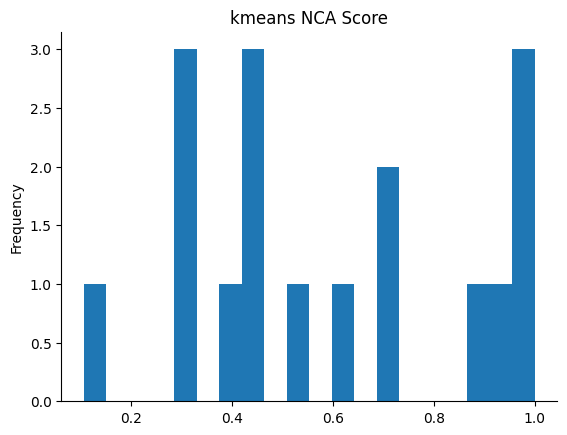

In [19]:
from matplotlib import pyplot as plt
df_baseline[f'{CLUSTERING_ALGO} NCA Score'].plot(kind='hist', bins=20, title=f'{CLUSTERING_ALGO} NCA Score')
plt.gca().spines[['top', 'right',]].set_visible(False)

## Execute get_scores_with_autoencoder on all datasets trying different numbers of embeddings (last hidden layer of the neural network)



In [26]:
scores_lists = {}
for battery in battery_datasets_dict.keys():
  for dataset in battery_datasets_dict[battery]:
    column_name = f'{CLUSTERING_ALGO}+{FEAT_ENG_ALGO} NCA Score'
    if column_name not in scores_lists:
      scores_lists[column_name] = []
    scores_lists[column_name].append(get_scores_with_feat_eng(battery, dataset))

df_ssnn = pd.DataFrame.from_dict(scores_lists)

In [27]:
df = pd.concat([df_baseline, df_ssnn], axis=1)

# Final Results

In [29]:
def highlight_scores(row):
    color = 'yellow'
    if row[f'{CLUSTERING_ALGO} NCA Score'] < 0.8 and \
     (row[f'{CLUSTERING_ALGO}+{FEAT_ENG_ALGO} NCA Score'] > row[f'{CLUSTERING_ALGO} NCA Score']):
        return [f'background-color: {color}'] * len(row)
    return [''] * len(row)

df.style.apply(highlight_scores, axis=1)

,Battery,Dataset,kmeans NCA Score,kmeans+ssnn NCA Score
0,fcps,atom,0.427500,0.892500
1,fcps,chainlink,0.306000,0.968000
2,fcps,engytime,0.902832,0.582520
3,fcps,hepta,1.000000,1.000000
4,fcps,lsun,0.690000,0.785000
5,fcps,target,0.704810,0.137002
6,fcps,tetra,1.000000,0.640000
7,fcps,twodiamonds,1.000000,0.040000
8,fcps,wingnut,0.927165,0.423228
9,uci,ecoli,0.433138,0.288668
